In [ ]:
import kagglehub
import os
import matplotlib.pyplot as plt
# from googletrans import Translator
from tqdm import tqdm
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader,random_split
from torchvision import transforms
from transformers import CLIPTokenizer, CLIPProcessor, CLIPModel, CLIPImageProcessor
from PIL import Image
import torch.nn as nn
from torch.optim import AdamW
import cv2
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [ ]:
path = kagglehub.dataset_download("adityajn105/flickr30k")

100%|██████████| 8.16G/8.16G [01:57<00:00, 74.3MB/s]

Extracting files...


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

folders = os.listdir(path)
print("Folders in path:", folders)
images_folder=path+"/"+folders[0]
captions_folder=path+"/"+folders[1]

image_names = os.listdir(images_folder)
image_names.sort()

print("Number of images:", len(image_names))

Folders in path: ['Images', 'captions.txt']
Number of images: 31785


In [ ]:
captions_folder

'/root/.cache/kagglehub/datasets/adityajn105/flickr30k/versions/1/captions.txt'

In [ ]:
from google.colab import files
files.download(captions_folder)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def extract_image_data(file_path):
    image_data_dict = {}
    translator = Translator()

    with open(file_path, 'r') as file:
        lines = file.readlines()

        for line in tqdm(lines[1:], desc="Processing captions", unit="line"):
            image_name, caption = line.strip().split(",", 1)

            if image_name not in image_data_dict:
                image_data_dict[image_name] = ImageData(image_name)

            translated_caption = translator.translate(text=caption, src='en', dest='fa').text

            image_data_dict[image_name].add_caption(caption)
            image_data_dict[image_name].add_translated_caption(translated_caption)

    return list(image_data_dict.values())


image_data_list = extract_image_data(captions_folder)
print("Number of images:", len(image_data_list))




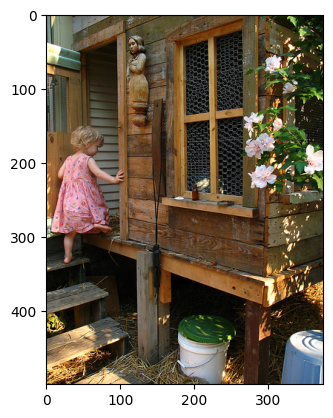

Captions:
- A child in a pink dress is climbing up a set of stairs in an entry way .
- A girl going into a wooden building .
- A little girl climbing into a wooden playhouse .
- A little girl climbing the stairs to her playhouse .
- A little girl in a pink dress going into a wooden cabin .
- کودکی با لباس صورتی در حال بالا رفتن از مجموعه ای از پله ها به صورت ورودی است.
- دختری که وارد یک ساختمان چوبی می شود.
- دختر بچه ای در حال بالا رفتن از یک خانه بازی چوبی.
- دختر بچه ای که از پله ها به سمت خانه بازی اش بالا می رود.
- دختر بچه ای با لباس صورتی که وارد یک کابین چوبی می شود.


In [ ]:
for image_data in image_data_list[0:1]:
    image_path = images_folder + "/" + image_data.image_name
    image = plt.imread(image_path)
    plt.imshow(image)
    plt.show()
    print("Captions:")
    for caption in image_data.captions:
        print(f"- {caption}")
    for translated_caption in image_data.translated_captions:
        print(f"- {translated_caption}")

In [ ]:
def write_captions_to_file(image_data_list, output_file):
    with open(output_file, 'w', encoding='utf-8') as file:
        for image_data in tqdm(image_data_list, desc="Processing images"):
            for caption in image_data.captions:
                file.write(f"{image_data.image_name},{caption} .\n")
            for translated_caption in image_data.translated_captions:
                file.write(f"{image_data.image_name},{translated_caption} .\n")

# Example usage
output_file = "captions_new.txt"
write_captions_to_file(image_data_list, output_file)

Processing images: 100%|██████████| 8091/8091 [00:00<00:00, 117011.40it/s]


In [ ]:
def read_captions_from_file(file_path):
    captions = []
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()

In [ ]:

output_file = "captions_new_30k_full.txt"

file1 = "/content/drive/MyDrive/Uni/DeepLearning/Project/captions_new_30k_p1.txt"
file2 = "/content/drive/MyDrive/Uni/DeepLearning/Project/captions_new_30k_p2.txt"
file3 = "/content/drive/MyDrive/Uni/DeepLearning/Project/captions_new_30k_p3.txt"
file4 = "/content/drive/MyDrive/Uni/DeepLearning/Project/captions_new_30k_p4.txt"

with open(output_file, 'w') as outfile:
    with open(file1, 'r') as f1:
        outfile.write(f1.read())

    with open(file2, 'r') as f2:
        outfile.write(f2.read())

    with open(file3, 'r') as f3:
        outfile.write(f3.read())

    with open(file4, 'r') as f4:
        outfile.write(f4.read())

In [ ]:
captions_30k_full_path = "/content/captions_new_30k.txt"
with open(captions_30k_full_path, 'r') as file:
    lines = file.readlines()

    for i,line in tqdm(enumerate(lines), desc="Processing captions", unit="line"):
        if i%10==0 and i+10<len(lines):
            image_name_i, caption_i = lines[i].strip().split(",", 1)
            image_name_i1, caption_i1 = lines[i+1].strip().split(",", 1)
            image_name_i2, caption_i2 = lines[i+2].strip().split(",", 1)
            image_name_i3, caption_i3 = lines[i+3].strip().split(",", 1)
            image_name_i4, caption_i4 = lines[i+4].strip().split(",", 1)
            image_name_i5, caption_i5 = lines[i+5].strip().split(",", 1)
            image_name_i6, caption_i6 = lines[i+6].strip().split(",", 1)
            image_name_i7, caption_i7 = lines[i+7].strip().split(",", 1)
            image_name_i8, caption_i8 = lines[i+8].strip().split(",", 1)
            image_name_i9, caption_i9 = lines[i+9].strip().split(",", 1)
            image_name_i10, caption_i10 = lines[i+10].strip().split(",", 1)

            if image_name_i == image_name_i1 and image_name_i == image_name_i2 and image_name_i == image_name_i3 and image_name_i == image_name_i4 and image_name_i == image_name_i5 and image_name_i == image_name_i6 and image_name_i == image_name_i7 and image_name_i == image_name_i8 and image_name_i == image_name_i9 and image_name_i != image_name_i10:
              continue
            else:
              print("error on line:",i)
              break




Processing captions: 317830line [00:00, 1268174.28line/s]


In [ ]:
captions_30k_fa_full_path = "/content/captions_new_30k_full.txt"
captions_30k_en_full_path = captions_folder
output_file="/content/captions_new_30k.txt"

with open(output_file, 'w') as outfile:
    with open(captions_30k_fa_full_path, 'r') as f1:
        with open(captions_30k_en_full_path, 'r') as f2:
            lines_fa = f1.readlines()
            lines_en = f2.readlines()[1:]

            if len(lines_fa) == len(lines_en):
              for i in range(int(len(lines_fa)/5) + 1):
                if i == len(lines_fa)/5:
                  for txt in lines_en[i*5:]:
                    outfile.write(txt)
                  for txt in lines_fa[i*5:]:
                    outfile.write(txt)
                else:
                  for txt in lines_en[i*5:(i*5)+5]:
                    outfile.write(txt)
                  for txt in lines_fa[i*5:(i*5)+5]:
                    outfile.write(txt)



In [ ]:
!cp /content/captions_new_30k.txt /content/drive/MyDrive/Uni/DeepLearning/FinalProject

# **Data Preproccessing**

In [ ]:
class ImageData:
    def __init__(self, image_name):
        self.image_name = image_name
        self.captions = []
        self.translated_captions = []

    def add_caption(self, caption):
        self.captions.append(caption)
        self.captions = list(np.squeeze(self.captions))

    def add_translated_caption(self, translated_caption):
        self.translated_captions.append(translated_caption)
        self.translated_captions = list(np.squeeze(self.translated_captions))


class ImageCaption:
    def __init__(self, image_name,caption):
        self.image_name = image_name
        self.caption = caption

class ImageCaptionDataset(Dataset):
    def __init__(self, captions_file, image_dir, image_proccessor, text_tokenizer, image_size=224):
        self.data = []
        self.data_en = []
        self.data_fa = []
        self.image_dir = image_dir
        self.image_proccessor=image_proccessor
        self.text_tokenizer=text_tokenizer

        self._load_data(captions_file)
        self.data = self.data_fa

    def _load_data(self, captions_file):
        with open(captions_file, 'r', encoding='utf-8') as file:
            lines = file.readlines()

        image_captions = {}

        for i,line in tqdm(enumerate(lines), desc="Processing captions", unit="line"):
            image_name, caption = line.strip().split(",", 1)
            caption = caption.strip(" .\"")

            if i%10 > 4:
              image_caption = ImageCaption(image_name, caption)
              self.data_fa.append(image_caption)
            else:
              image_caption = ImageCaption(image_name, caption)
              self.data_en.append(image_caption)

            # if image_name not in image_captions:
            #     image_captions[image_name] = {"english": [], "persian": []}

            # # Separate English and Persian captions based on count (first 5 are English, last 5 are Persian)
            # captions = image_captions[image_name]
            # if len(captions["english"]) < 5:
            #     captions["english"].append(caption)
            # else:
            #     captions["persian"].append(caption)

        # Flatten the dictionary into a list of tuples
        # for image_name, captions in image_captions.items():
        #     image_data = ImageData(image_name)
        #     image_data.add_caption(captions["english"])
        #     image_data.add_translated_caption(captions["persian"])
        #     self.data.append(image_data)


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image_path = f"{self.image_dir}/{item.image_name}"
        image = Image.open(image_path).convert("RGB")
        image = self.image_proccessor(images=image, return_tensors="pt")["pixel_values"].squeeze()

        tokenized_caption = self.text_tokenizer(
            item.caption,
            padding="max_length",  # Pad to the maximum length
            truncation=True,
            max_length=64,       # Set a fixed maximum length
            return_tensors="pt"
        )

        return {
            "image_path": image_path,
            "image": image,
            "caption": tokenized_caption["input_ids"],
            "attention_mask": tokenized_caption["attention_mask"],
            "caption_raw": item.caption
        }


def create_and_spilt_dataset(image_processor, text_tokenizer):
    captions_path = "/content/captions_new_30k.txt"
    dataset = ImageCaptionDataset(captions_path, images_folder, image_processor, text_tokenizer, 224)

    batch_size=16
    test_split=0.06

    test_size = int(len(dataset) * test_split)
    train_size = len(dataset) - test_size

    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_dataset, test_dataset, train_loader, test_loader


# **Fine-Tune**

In [ ]:
class CLIPFineTuner:
    def __init__(self, model_name, device):
        self.device = device
        self.model = CLIPModel.from_pretrained(model_name).to(self.device)
        self.processor = CLIPProcessor.from_pretrained(model_name)

        _, _, self.train_loader, self.val_loader = create_and_spilt_dataset(self.processor.image_processor, self.processor.tokenizer)

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = AdamW(self.model.parameters(), lr=5e-6)

    def train_epoch(self):
        self.model.train()
        total_loss = 0

        for batch in tqdm(self.train_loader, desc="Training", unit="batch"):
            images = batch["image"].to(self.device)
            captions = batch["caption"].to(self.device)
            attention_mask = np.squeeze(batch["attention_mask"]).to(self.device)
            # print("Images ",images.shape)
            # print("Captions ",captions.shape)
            # print("Attention mask ",attention_mask.shape)

            # Forward pass
            outputs = self.model(pixel_values=images, input_ids=captions, attention_mask=attention_mask)
            logits_per_image = outputs.logits_per_image  # Image-to-text logits
            logits_per_text = outputs.logits_per_text    # Text-to-image logits
            # print("logits_per_image ",logits_per_image.shape)
            # print("logits_per_text ",logits_per_text.shape)

            # print("image probs: ",logits_per_image.softmax(dim=-1))
            # print("text probs: ",logits_per_text.softmax(dim=-1))


            # Labels for contrastive learning
            labels = torch.arange(images.size(0), device=self.device)
            # print("labels ",labels.shape)
            # print("labels ",labels)

            # Compute loss
            loss = (self.criterion(logits_per_image, labels) + self.criterion(logits_per_text, labels)) / 2

            # Backpropagation
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def validate_epoch(self):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="Validation", unit="batch"):
                images = batch["image"].to(self.device)
                captions = np.squeeze(batch["caption"]).to(self.device)
                attention_mask = np.squeeze(batch["attention_mask"]).to(self.device)


                # Forward pass
                outputs = self.model(pixel_values=images, input_ids=captions, attention_mask=attention_mask)
                logits_per_image = outputs.logits_per_image
                logits_per_text = outputs.logits_per_text

                labels = torch.arange(images.size(0), device=self.device)

                # Compute loss
                loss = (self.criterion(logits_per_image, labels) + self.criterion(logits_per_text, labels)) / 2

                total_loss += loss.item()

        return total_loss / len(self.val_loader)

    def train(self, epochs):
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            train_loss = self.train_epoch()
            val_loss = self.validate_epoch()

            print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

# Initialize Fine-Tuner
fine_tuner = CLIPFineTuner("openai/clip-vit-base-patch32", device)

# Train the model
fine_tuner.train(epochs=2)

# Save the fine-tuned model
fine_tuner.model.save_pretrained("fine_tuned_clip_model_30k_e2")
fine_tuner.processor.save_pretrained("fine_tuned_clip_processor_30k_e2")

!zip -r fine_tuned_clip_model_30k_e2.zip /content/fine_tuned_clip_model_30k_e2
!zip -r fine_tuned_clip_processor_30k_e2.zip /content/fine_tuned_clip_processor_30k_e2

!cp fine_tuned_clip_model_30k_e2.zip /content/drive/MyDrive/Uni/DeepLearning/FinalProject
!cp fine_tuned_clip_processor_30k_e2.zip /content/drive/MyDrive/Uni/DeepLearning/FinalProject

Processing captions: 317830line [00:01, 238458.48line/s]



Epoch 1/2


Training:   1%|          | 85/9337 [00:28<51:31,  2.99batch/s]


KeyboardInterrupt: 

In [ ]:
!zip -r fine_tuned_clip_processor.zip /content/fine_tuned_clip_processor

  adding: content/fine_tuned_clip_processor/ (stored 0%)
  adding: content/fine_tuned_clip_processor/preprocessor_config.json (deflated 50%)
  adding: content/fine_tuned_clip_processor/special_tokens_map.json (deflated 78%)
  adding: content/fine_tuned_clip_processor/vocab.json (deflated 62%)
  adding: content/fine_tuned_clip_processor/tokenizer.json (deflated 83%)
  adding: content/fine_tuned_clip_processor/tokenizer_config.json (deflated 63%)
  adding: content/fine_tuned_clip_processor/merges.txt (deflated 60%)


In [ ]:
!cp fine_tuned_clip_processor.zip /content/drive/MyDrive/Uni/DeepLearning/FinalProject

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Inference**

In [ ]:
!unzip /content/drive/MyDrive/Uni/DeepLearning/Project/fine_tuned_clip_model.zip -d /content/
!unzip /content/drive/MyDrive/Uni/DeepLearning/Project/fine_tuned_clip_processor.zip -d /content/

Archive:  /content/drive/MyDrive/Uni/DeepLearning/Project/fine_tuned_clip_model.zip
   creating: /content/content/fine_tuned_clip_model/
  inflating: /content/content/fine_tuned_clip_model/config.json  
  inflating: /content/content/fine_tuned_clip_model/model.safetensors  
Archive:  /content/drive/MyDrive/Uni/DeepLearning/Project/fine_tuned_clip_processor.zip
   creating: /content/content/fine_tuned_clip_processor/
  inflating: /content/content/fine_tuned_clip_processor/preprocessor_config.json  
  inflating: /content/content/fine_tuned_clip_processor/special_tokens_map.json  
  inflating: /content/content/fine_tuned_clip_processor/vocab.json  
  inflating: /content/content/fine_tuned_clip_processor/tokenizer.json  
  inflating: /content/content/fine_tuned_clip_processor/tokenizer_config.json  
  inflating: /content/content/fine_tuned_clip_processor/merges.txt  


In [ ]:
from torch.utils.data import DataLoader, Subset

def encode_frame_base(model, test_loader):
    model.eval()
    frameBaseEncoded = []
    paths = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="encoding frameBase", unit="batch"):
            image_paths = batch["image_path"]
            images = batch["image"].to(device)

            image_embeddings = model.get_image_features(pixel_values=images)
            image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)  # Normalize embedding

            for path,embedding in zip(image_paths, image_embeddings.cpu()):
                if path not in paths:
                  paths.append(path)
                  frameBaseEncoded.append((path, embedding))
    print("frameBaseEncoded",len(frameBaseEncoded))
    return frameBaseEncoded


# Step 3: Encode a sample input text and compute similarities
def inference(frameBaseEncoded, text, model, processor):
    text_inputs = processor(text=[text], images=None, return_tensors="pt", padding=True, truncation=True).to(device)

    with torch.no_grad():
        text_embedding = model.get_text_features(**text_inputs)
        text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)  # Normalize embedding

    # Compute similarities
    similarities = []
    for image_path, image_embedding in frameBaseEncoded:
        image_embedding = image_embedding.to(device)
        similarity = torch.cosine_similarity(text_embedding, image_embedding, dim=-1).item()
        similarities.append((image_path, similarity))

    # Sort by similarity and get top 5 matches
    top_matches = sorted(similarities, key=lambda x: x[1], reverse=True)[:5]

    # Print the results
    print("Top 5 Matches:")
    for image_path, similarity in top_matches:
        print(f"Image: {image_path}, Similarity: {similarity:.4f}")
        image = plt.imread(image_path)
        plt.imshow(image)
        plt.show()

def AUC_score(model, processor, test_loader):
    model.eval()

    # subset of test_loader
    subset_dataset = Subset(test_loader.dataset, range(200))
    subset_loader = DataLoader(subset_dataset, batch_size=16, shuffle=False, num_workers=2)

    frameBaseEncoded = []
    paths = []
    frameCaptions = []
    with torch.no_grad():
        for batch in tqdm(subset_loader, desc="encoding frameBase", unit="batch"):
            image_paths = batch["image_path"]
            images = batch["image"].to(device)
            captions = np.squeeze(batch["caption_raw"])

            image_embeddings = model.get_image_features(pixel_values=images)
            image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)  # Normalize embedding

            for path,embedding in zip(image_paths, image_embeddings.cpu()):
              if path not in paths:
                paths.append(path)
                frameBaseEncoded.append((path, embedding))

            for caption in captions:
                frameCaptions.append((path, caption))


        print("frameCaptions",len(frameCaptions))
        print("frameBaseEncoded",len(frameBaseEncoded))

        AUC_score = 0
        # for path,caption in tqdm(frameCaptions, desc="evaluating sims", unit="batch"):

        for path,caption in frameCaptions:
            text_inputs = processor(text=[caption], images=None, return_tensors="pt", padding=True, truncation=True).to(device)

            with torch.no_grad():
                text_embedding = model.get_text_features(**text_inputs)
                text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)  # Normalize embedding

            similarities = []
            for image_path, image_embedding in frameBaseEncoded:
                image_embedding = image_embedding.to(device)
                similarity = torch.cosine_similarity(text_embedding, image_embedding, dim=-1).item()
                similarities.append((image_path, similarity))

            sim_scores = [similarity for path,similarity in similarities]

            ground_truth = np.zeros_like(sim_scores)
            for i, (image_path, _) in enumerate(similarities):
                if image_path == path:
                    ground_truth[i] = 1

            true_index = np.argmax(ground_truth)
            lalel_score = sim_scores[true_index]
            sorted_sim_scores = sorted(sim_scores,reverse=True)
            label_score_index = sorted_sim_scores.index(lalel_score)

            # fpr, tpr, thresholds = roc_curve(ground_truth, sim_scores)
            # AUC_score += auc(fpr, tpr)
            score =roc_auc_score(ground_truth, sim_scores)
            AUC_score += score
            print("label_score_index",label_score_index, "AUC", score)



        AUC_score /= len(frameCaptions)
        print("AUC score: ",AUC_score)
        return AUC_score

## Fined-tuned Model

In [ ]:
fine_tuned_model_path = "/content/content/fine_tuned_clip_model"
fine_tuned_processor_path = "/content/content/fine_tuned_clip_processor"
fine_tuned_model = CLIPModel.from_pretrained(fine_tuned_model_path)
fine_tuned_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fine_tuned_model.to(device)

fine_tuned_processor = CLIPProcessor.from_pretrained(fine_tuned_processor_path)

In [ ]:
fine_tuned_train_dataset, fine_tuned_test_dataset, fine_tuned_train_loader, fine_tuned_test_loader = create_and_spilt_dataset(fine_tuned_processor.image_processor, fine_tuned_processor.tokenizer)

fine_tuned_frameBaseEncoded = encode_frame_base(fine_tuned_model, fine_tuned_test_loader)

Processing captions: 80910line [00:00, 171389.15line/s]


Top 5 Matches:
Image: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images/3084380974_268a0f9236.jpg, Similarity: 0.3069


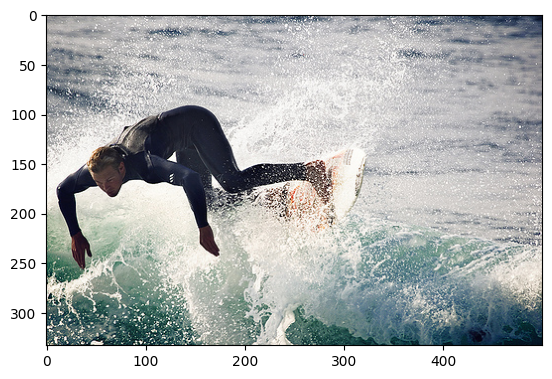

Image: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images/3071676551_a65741e372.jpg, Similarity: 0.3045


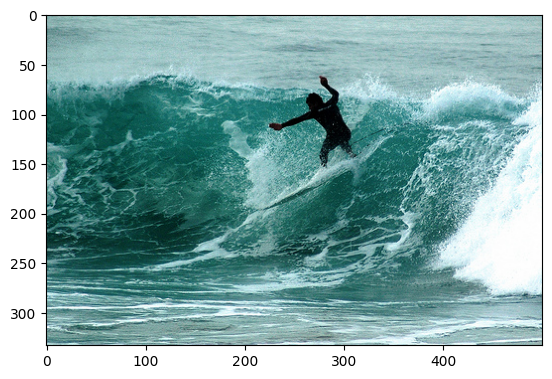

Image: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images/3116011063_f4071ccce6.jpg, Similarity: 0.3007


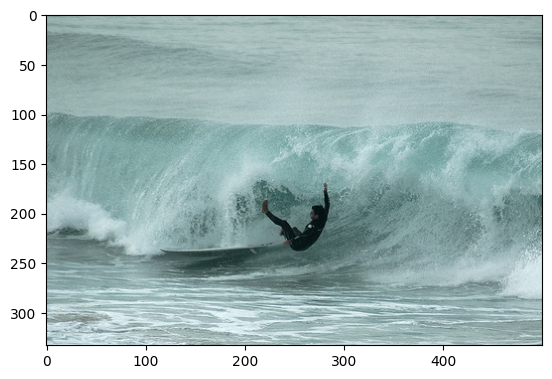

Image: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images/3183519385_311555d5f5.jpg, Similarity: 0.3002


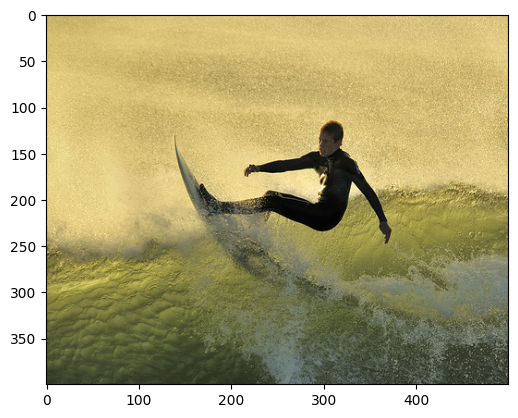

Image: /root/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1/Images/3214151585_f2d0b00b41.jpg, Similarity: 0.2991


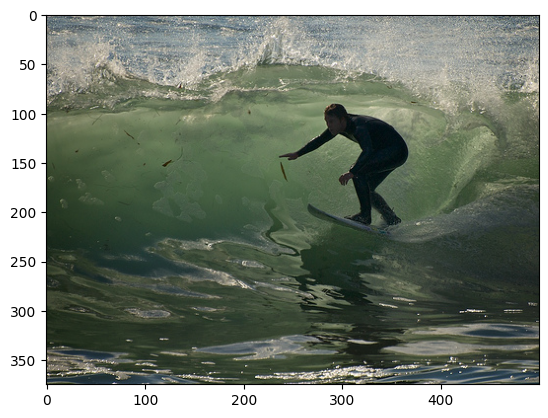

In [ ]:
inference(fine_tuned_frameBaseEncoded, "موج سواری", fine_tuned_model, fine_tuned_processor)

## OpenAi model

In [ ]:
# OPENAI model
model_name="openai/clip-vit-base-patch32"
open_model = CLIPModel.from_pretrained(model_name).to(device)
open_model.eval()
open_processor = CLIPProcessor.from_pretrained(model_name)

In [ ]:
open_train_dataset, open_test_dataset, open_train_loader, open_test_loader = create_and_spilt_dataset(open_processor.image_processor, open_processor.tokenizer)

Processing captions: 317830line [00:00, 501146.46line/s]


In [ ]:
open_frameBaseEncoded = encode_frame_base(open_model, open_test_loader)

In [ ]:
inference(open_frameBaseEncoded, "A brown and white dog stands outside while it snows", open_model, open_processor)

In [ ]:
AUC_score(open_model, open_processor, open_test_loader)

encoding frameBase: 100%|██████████| 13/13 [00:01<00:00,  6.92batch/s]


frameCaptions 200
frameBaseEncoded 199
label_score_index 185 AUC 0.06565656565656564
label_score_index 175 AUC 0.11616161616161613
label_score_index 185 AUC 0.06565656565656564
label_score_index 189 AUC 0.045454545454545414
label_score_index 142 AUC 0.2828282828282829
label_score_index 174 AUC 0.12121212121212122
label_score_index 165 AUC 0.16666666666666663
label_score_index 192 AUC 0.030303030303030276
label_score_index 151 AUC 0.23737373737373735
label_score_index 193 AUC 0.025252525252525304
label_score_index 146 AUC 0.26262626262626265
label_score_index 185 AUC 0.06565656565656564
label_score_index 174 AUC 0.12121212121212122
label_score_index 128 AUC 0.3535353535353535
label_score_index 183 AUC 0.0757575757575758
label_score_index 122 AUC 0.38383838383838387
label_score_index 102 AUC 0.48484848484848486
label_score_index 29 AUC 0.8535353535353536
label_score_index 105 AUC 0.4696969696969697
label_score_index 55 AUC 0.7222222222222222
label_score_index 46 AUC 0.7676767676767677
la

0.4999494949494948

In [ ]:
y_true = [1, 0, 0, 0, 0]

# Predicted probabilities or similarity scores
y_scores = [0.33, 0.32, 0.05, 0.22, 0.25]

# Compute AUC
auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

AUC: 1.0


# **Video Inference**

In [ ]:
model_name="openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mistag/short-videos")

print("Path to dataset files:", path)
folders = os.listdir(path)

videoBase=[]
for folder in folders[1:]:
    folder_path=path+"/"+folder
    videos = os.listdir(folder_path)
    videos.sort()
    for video in videos:
      videoBase.append(folder_path+"/"+video)

test_video_path = "/content/drive/MyDrive/Uni/Deep Learning/Project/test_video.mp4"

videoBase.append(test_video_path)
videoBase

Path to dataset files: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4


['/root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4',
 '/root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/animals/elefant_1280p.mp4',
 '/root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/animals/giraffes_1280p.mp4',
 '/root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/insects/butterflies_1280.mp4',
 '/root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/insects/butterflies_960p.mp4']

In [ ]:
videoFramesEncoded = []
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
])

for video_path in tqdm(videoBase, desc="Processing videos"):
    print(f"Processing video: {video_path}")
    cap = cv2.VideoCapture(video_path)
    frame_rate = int(cap.get(cv2.CAP_PROP_FPS))
    print(f"Frame rate: {frame_rate}")
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_rate == 0:
            # Convert frame to PIL image
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_image = Image.fromarray(frame_rgb)

            # Preprocess and encode the frame
            frame_tensor = image_transform(frame_image).unsqueeze(0).to(device)

            with torch.no_grad():
                frame_embedding = model.get_image_features(pixel_values=frame_tensor)
                frame_embedding = frame_embedding / frame_embedding.norm(dim=-1, keepdim=True)  # Normalize

            # Store the encoded frame, frame number, and video path
            videoFramesEncoded.append((frame_embedding.cpu(), frame_count, video_path))

        frame_count += 1

    cap.release()

Processing videos:   0%|          | 0/5 [00:00<?, ?it/s]

Processing video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4
Frame rate: 29


Processing videos:  20%|██        | 1/5 [00:04<00:16,  4.21s/it]

Processing video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/animals/elefant_1280p.mp4
Frame rate: 29


Processing videos:  40%|████      | 2/5 [00:11<00:18,  6.26s/it]

...

Processing videos:  60%|██████    | 3/5 [00:21<00:15,  8.00s/it]

Processing video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/insects/butterflies_1280.mp4
Frame rate: 29


Processing videos:  80%|████████  | 4/5 [00:32<00:09,  9.12s/it]

Processing video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/insects/butterflies_960p.mp4
Frame rate: 29


Processing videos: 100%|██████████| 5/5 [00:38<00:00,  7.69s/it]


In [ ]:
videoFramesEncoded[0][2]

'/root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4'

Top 5 Matches:
Video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4, Frame: 116, Similarity: 0.2398


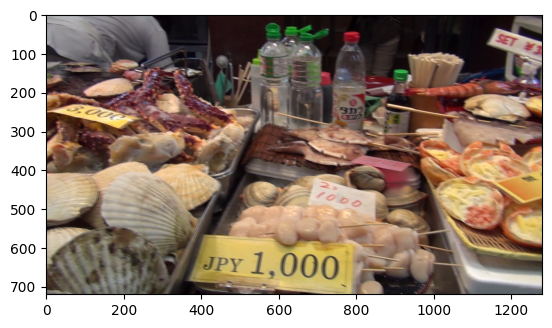

Video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4, Frame: 203, Similarity: 0.2381


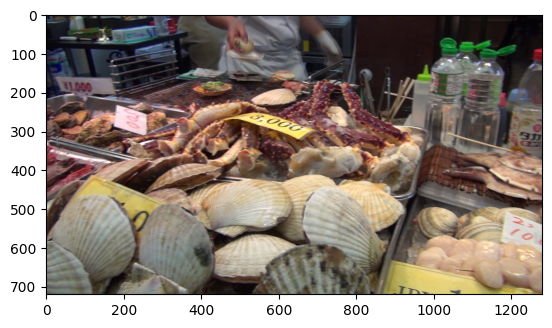

Video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4, Frame: 145, Similarity: 0.2300


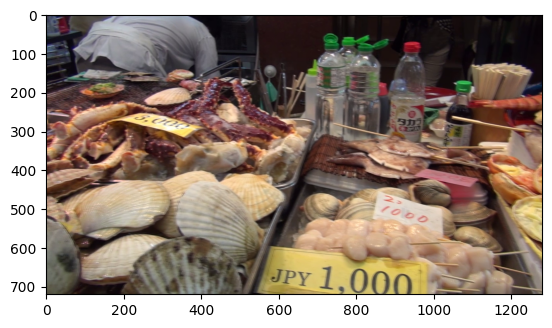

Video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4, Frame: 87, Similarity: 0.2267


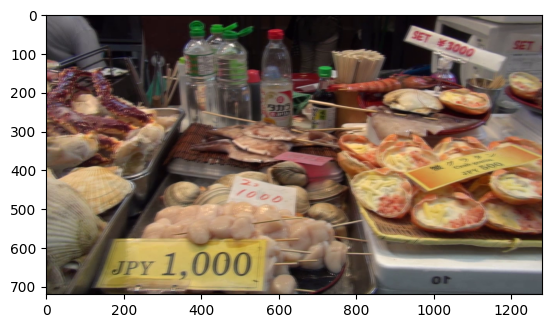

Video: /root/.cache/kagglehub/datasets/mistag/short-videos/versions/4/food/seafood_1280p.mp4, Frame: 29, Similarity: 0.2261


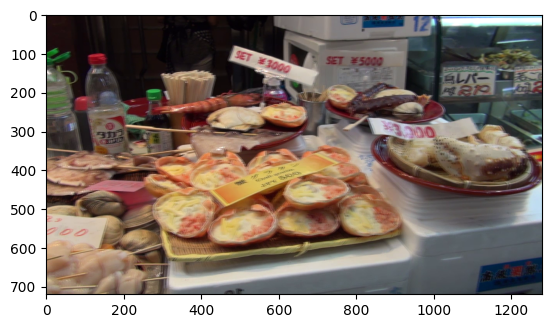

In [ ]:
# Step 3: Encode a sample input text and compute similarities
sample_text = "oyster"  # Replace with your query text
text_inputs = processor(text=[sample_text], images=None, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    text_embedding = model.get_text_features(**text_inputs)
    text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)  # Normalize embedding

# Compute similarities
similarities = []
for frame_embedding, frame_number, video_path in videoFramesEncoded:
    frame_embedding = frame_embedding.to(device)
    similarity = torch.cosine_similarity(text_embedding, frame_embedding, dim=-1).item()
    similarities.append((similarity, frame_number, video_path))

# Sort by similarity and get top 5 matches
top_matches = sorted(similarities, key=lambda x: x[0], reverse=True)[:5]

# Print the results
print("Top 5 Matches:")
for similarity, frame_number, video_path in top_matches:
    print(f"Video: {video_path}, Frame: {frame_number}, Similarity: {similarity:.4f}")
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.show()


In [ ]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
logits_per_text = outputs.logits_per_text  # this is the text-image similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

print("logits_per_image",logits_per_image)
print("logits_per_text",logits_per_text)
print("probs",probs)

logits_per_image tensor([[24.5700, 19.3049]], grad_fn=<TBackward0>)
logits_per_text tensor([[24.5700],
        [19.3049]], grad_fn=<MulBackward0>)
probs tensor([[0.9949, 0.0051]], grad_fn=<SoftmaxBackward0>)


In [ ]:
!zip -r fined_tuned_proccessor.zip /content/fine_tuned_clip_processor

  adding: content/fine_tuned_clip_processor/ (stored 0%)
  adding: content/fine_tuned_clip_processor/preprocessor_config.json (deflated 50%)
  adding: content/fine_tuned_clip_processor/special_tokens_map.json (deflated 78%)
  adding: content/fine_tuned_clip_processor/vocab.json (deflated 62%)
  adding: content/fine_tuned_clip_processor/tokenizer.json (deflated 83%)
  adding: content/fine_tuned_clip_processor/tokenizer_config.json (deflated 63%)
  adding: content/fine_tuned_clip_processor/merges.txt (deflated 60%)


In [ ]:
from google.colab import files
files.download("folder_name.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>